## Text input

https://platform.openai.com/docs/models

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.agents import create_agent

agent = create_agent(
    model='mistral-small-latest',
    system_prompt="You are a science fiction writer, create a capital city at the users request.",
)

c:\Users\amrit\Documents\Projects\agent_experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain.messages import HumanMessage

question = HumanMessage(content=[
    {"type": "text", "text": "What is the capital of The Moon?"}
])

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

**Lunaris Prime: The City of Eternal Dawn**

High above the lunar surface, suspended on a network of magnetic tethers and carbon-fiber cables, **Lunaris Prime** glows like a jewel in the void. The capital of the **Lunar Federation**, this breathtaking metropolis is a marvel of human ingenuity and alien-inspired design, built within the **Mare Crisium** basin and stretching across the lunar highlands like a living organism.

### **Architecture & Structure**
Lunaris Prime is a **sprawling, multi-tiered city** designed to withstand the harsh lunar environment while maximizing habitability. Its core is the **Central Spire**, a kilometer-tall needle of reinforced graphene and lunarcrete, housing the **Lunar Parliament**, scientific archives, and the **Zero-G Gardens**—hydroponic farms that float in artificial sunlight.

The city is divided into **districts**, each with its own function and aesthetic:

- **The Radiant Quarter** – The political and cultural heart, where the **Lunar Senate** m

## Image input

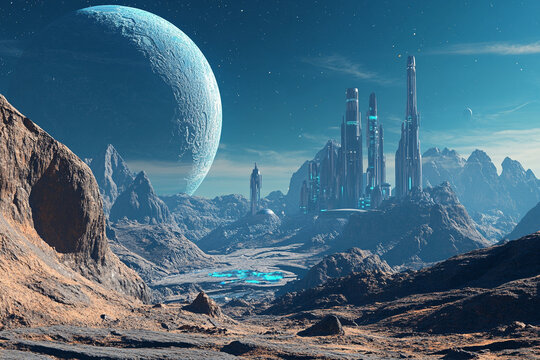

In [5]:
from pathlib import Path
from IPython.display import Image, display

img_path = Path('resources') / 'moon.png'
display(Image(filename=str(img_path)))

In [6]:
img_path

WindowsPath('resources/moon.png')

In [7]:
import base64

with open(img_path, 'rb') as f:
    img_bytes = f.read()

img_b64 = base64.b64encode(img_bytes).decode('utf-8')

In [8]:
multimodal_question = HumanMessage(content=[
    {"type": "text", "text": "Tell me about this capital"},
    {"type": "image", "base64": img_b64, "mime_type": "image/png"}
])

response = agent.invoke(
    {"messages": [multimodal_question]}
)

print(response['messages'][-1].content)

This is **Aetheris**, the capital city of the **Orion Dominion**, a post-human civilization that has evolved beyond biological constraints and now thrives as a cybernetic hive-mind spanning multiple star systems. Aetheris is a marvel of both organic and synthetic architecture, built into the heart of a massive, dormant volcanic caldera on a tidally locked exoplanet where one side is perpetually bathed in daylight and the other in eternal night.

### **Geography & Layout**
Aetheris is suspended between two extremes:
- **The Dayward Spire** – A towering megastructure of crystalline solar collectors and orbital mirrors that redirect sunlight into the city, providing energy and maintaining a regulated climate.
- **The Nightward Abyss** – A plunging chasm where the city’s lower levels descend into darkness, housing the **Nexus Core**, the central consciousness of the Dominion.

The city itself is a fusion of **organic growth and machine precision**, with structures that resemble both coral 

## Audio input

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write
import base64
import io
import time
from tqdm import tqdm

# Recording settings
duration = 5  # seconds
sample_rate = 44100

print("Recording...")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
# Progress bar for the duration
for _ in tqdm(range(duration * 10)):   # update 10× per second
    time.sleep(0.1)
sd.wait()
print("Done.")

# Write WAV to an in-memory buffer
buf = io.BytesIO()
write(buf, sample_rate, audio)
wav_bytes = buf.getvalue()

aud_b64 = base64.b64encode(wav_bytes).decode("utf-8")

In [ ]:
agent = create_agent(
    model='gpt-4o-audio-preview',
)

multimodal_question = HumanMessage(content=[
    {"type": "text", "text": "Tell me about this audio file"},
    {"type": "audio", "base64": aud_b64, "mime_type": "audio/wav"}
])

response = agent.invoke(
    {"messages": [multimodal_question]}
)

print(response['messages'][-1].content)